## PRACTICA EE: ESTRATEGIAS EVOLUTIVAS

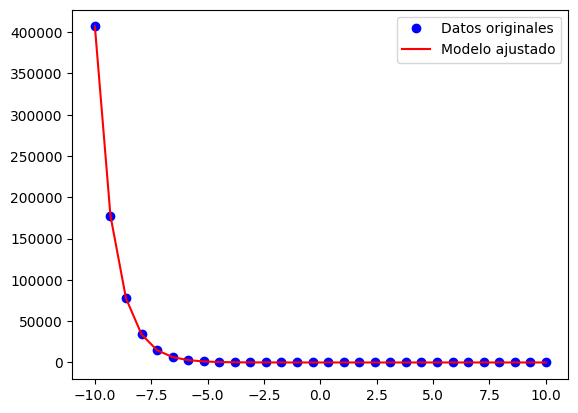

C:\Users\mateo\AppData\Local\Temp\ipykernel_2796\1917294970.py:64: RuntimeWarning: overflow encountered in scalar power
  error = (fun_obj(individuo[0], individuo[1], individuo[2], xi) - yi) ** 2


Algoritmo de estrategia evolutiva
Mejor solucion encontrada:  [2.4999999999990252, -1.2000000000000395, 0.8140776629661559, 2.4544276002716594e-20, 5.963904111075162e-18, 6.189672150540298e-20]


In [2]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

#Funciones
def f(x,a=2.5,b=-1.2,c=0.8):
    return a * np.e**(b*x) + c + np.random.normal(0,0.05)

#función fitness
def fun_obj(a,b,c,x):
    return a * np.e**(b*x) + c

#Función para iniciar un individuo:
def ini_ind(Imin,Imax):
    a = random.uniform(Imin,Imax)
    b = random.uniform(Imin,Imax)
    c = random.uniform(Imin,Imax)
    sigma1 = random.uniform(0.1,1.0) #Estrategia inicial descrita en la literatura
    sigma2 = random.uniform(0.1,1.0)
    sigma3 = random.uniform(0.1,1.0)
    return [a,b,c,sigma1,sigma2,sigma3]

#Mutación adaptativa
def mutacion(individuo,Imin,Imax):
    n= 3 #Dimensión
    tau = 1/math.sqrt(2*math.sqrt(n))
    tau_prima = 1/math.sqrt(2*n)

    #Ruido global y local
    N0 = random.gauss(0,0.05)
    individuo[3] *= math.exp(tau_prima*N0 + tau * random.gauss(0,1))
    individuo[4] *= math.exp(tau_prima*N0 + tau * random.gauss(0,1))
    individuo[5] *= math.exp(tau_prima*N0 + tau * random.gauss(0,1))

    # Mutación en variabels de decisión
    individuo[0] += individuo[3]*random.gauss(0,1)
    individuo[1] += individuo[4]*random.gauss(0,1)
    individuo[2] += individuo[5]*random.gauss(0,1)

    #Restringimos el dominio
    if individuo[0] < Imin:
        individuo[0] = Imin
    if individuo[0] > Imax:
        individuo[0] = Imax
    if individuo[1] < Imin:
        individuo[1] = Imin
    if individuo[1] > Imax:
        individuo[1] = Imax
    if individuo[2] < Imin:
        individuo[2] = Imin
    if individuo[2] > Imax:
        individuo[2] = Imax
    return individuo

def seleccion_mu_labda(poblacion, mu, x_vals, y_vals):
    pob_ordenada = sorted(poblacion, key=lambda ind: error_cuad(ind, x_vals, y_vals))
    return pob_ordenada[:mu]


def error_cuad(individuo, x_vals, y_vals):
    errores_cuad = []
    for xi, yi in zip(x_vals, y_vals):
        error = (fun_obj(individuo[0], individuo[1], individuo[2], xi) - yi) ** 2
        errores_cuad.append(error)
    return np.sum(errores_cuad) / len(errores_cuad)

#------------------ Algoritmo principal--------------
x = np.linspace(-10,10,30)
y = f(x)
plt.plot(x, y, 'bo', label='Datos originales')
plt.plot(x, fun_obj(mejor[0], mejor[1], mejor[2], x), 'r-', label='Modelo ajustado')
plt.legend()
plt.show()


Imin = -50
Imax = 50
mu = 50
lambd = 200
generaciones = 2000
#Se crea la poblacion inicial
P=[]
for i in range(mu):
    P.append(ini_ind(Imin,Imax))

#Evolución
errores = []  # Lista para guardar el error del mejor en cada generación

for g in range(generaciones):
    offspring = []
    for i in range(lambd):
        padre = random.choice(P)
        hijo = padre.copy()
        hijo = mutacion(hijo, Imin, Imax)
        offspring.append(hijo)

    P = seleccion_mu_labda(offspring + P, mu, x, y)
    mejor = P[0]

    # Calcular error del mejor individuo y guardarlo
    err = error_cuad(mejor, x, y)
    errores.append(err)

print("Algoritmo de estrategia evolutiva")
print("Mejor solucion encontrada: ", mejor)